In [3]:
# Cell 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Cell 2 — Safer connection method
import pandas as pd
import mysql.connector

# Connect directly with mysql.connector
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rounak@2206',        # ← put your password here between the quotes
    database='churn_analysis'
)

df = pd.read_sql('SELECT * FROM telco_churn', con=conn)

print(f"✅ Data loaded! Shape: {df.shape}")
df.head()

C:\Users\Rounak\AppData\Local\Temp\ipykernel_22508\2506435115.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM telco_churn', con=conn)


✅ Data loaded! Shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check data types and missing values
print(df.info())
print("\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [6]:
# Fix TotalCharges and encode Churn
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Data cleaned!")
print(df['Churn'].value_counts())

✅ Data cleaned!
Churn
0    5163
1    1869
Name: count, dtype: int64


C:\Users\Rounak\AppData\Local\Temp\ipykernel_22508\2796618107.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


C:\Users\Rounak\AppData\Local\Temp\ipykernel_22508\3279325885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


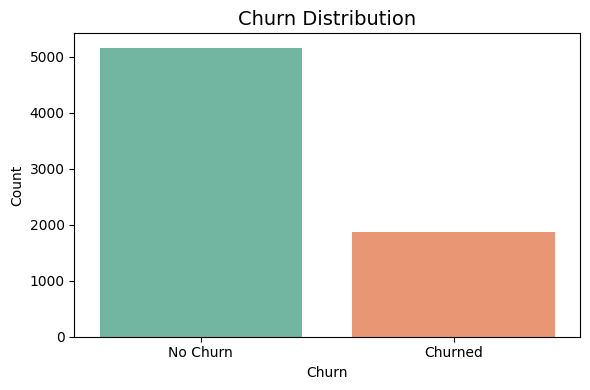

In [7]:
# Churn distribution chart
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution', fontsize=14)
plt.xticks([0,1], ['No Churn', 'Churned'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png')
plt.show()

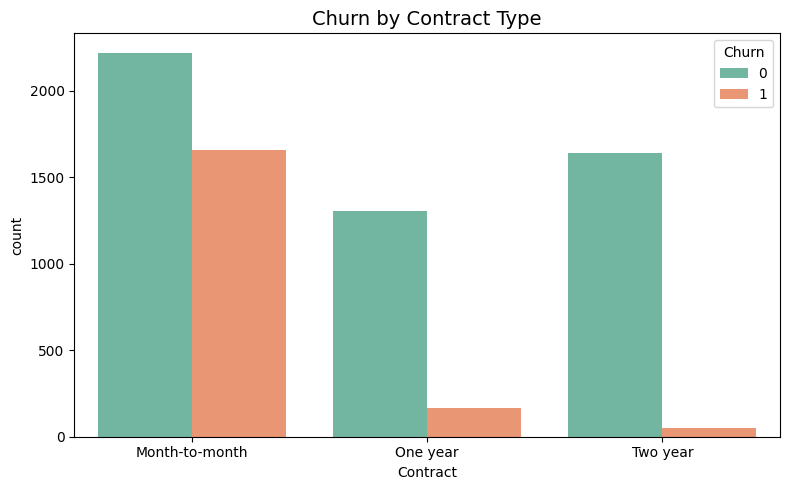

In [9]:
# Churn by Contract type
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type', fontsize=14)
plt.tight_layout()
plt.savefig('churn_by_contract.png')
plt.show()

C:\Users\Rounak\AppData\Local\Temp\ipykernel_22508\1118323409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


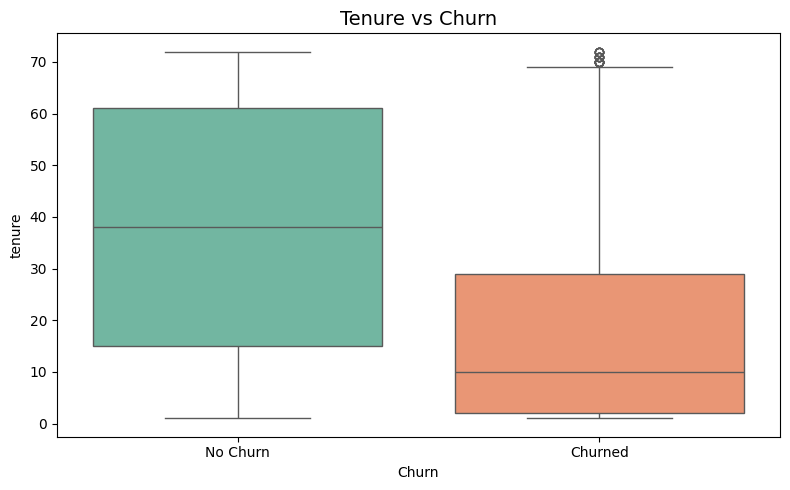

In [10]:
# Churn by Tenure (Box Plot)
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tenure vs Churn', fontsize=14)
plt.xticks([0,1], ['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('tenure_vs_churn.png')
plt.show()

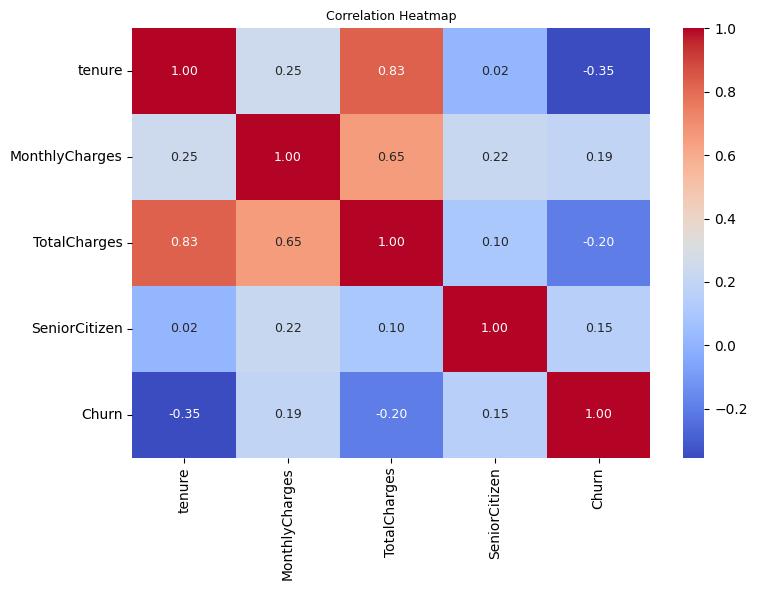

In [17]:
plt.figure(figsize=(8,6))  # reduced from (12,8)
sns.heatmap(df_encoded[['tenure','MonthlyCharges','TotalCharges',
                          'SeniorCitizen','Churn']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f',
            annot_kws={"size": 9})  # smaller font inside boxes
plt.title('Correlation Heatmap', fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [18]:
 # Feature Engineering
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Drop customerID (not useful for prediction)
df_model.drop('customerID', axis=1, inplace=True)

# Encode all object columns
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

print("✅ All features encoded!")
print(df_model.shape)
df_model.head()

✅ All features encoded!
(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [19]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train size: {X_train.shape}")
print(f"✅ Test size:  {X_test.shape}")

✅ Train size: (5625, 19)
✅ Test size:  (1407, 19)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print(f"✅ Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"✅ AUC Score: {roc_auc_score(y_test, y_prob):.2f}")
print("\n", classification_report(y_test, y_pred))

✅ Accuracy:  78.75%
✅ AUC Score: 0.83

               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



C:\Users\Rounak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
 # Fix Convergence + Add Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain Logistic Regression with scaling
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print(f"✅ Logistic Regression AUC: {roc_auc_score(y_test, y_prob_lr):.2f}")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")

✅ Logistic Regression AUC: 0.83
✅ Accuracy: 78.54%


In [22]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(f"✅ Random Forest AUC:  {roc_auc_score(y_test, y_prob_rf):.2f}")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")

✅ Random Forest AUC:  0.81
✅ Accuracy: 79.25%


C:\Users\Rounak\AppData\Local\Temp\ipykernel_22508\3857569291.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='coolwarm')


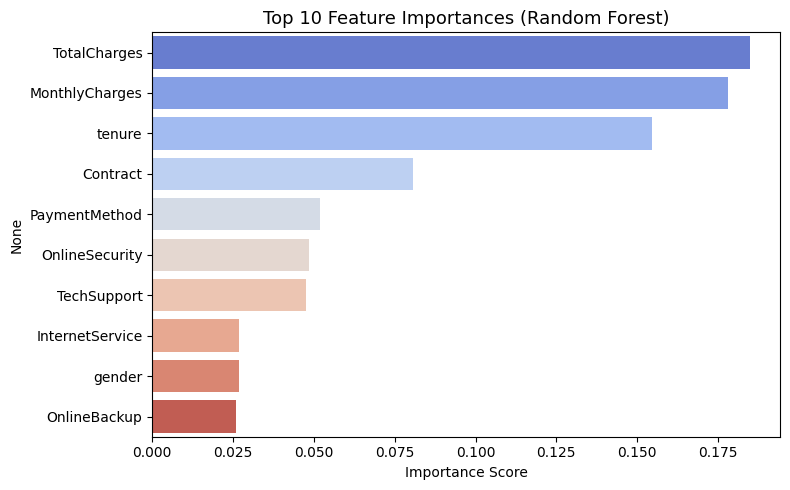

In [24]:
# Feature Importance Chart ⭐
import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='coolwarm')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [25]:
# Add churn probability from our best model to the dataframe
df_export = df.copy()
df_export['churn_probability'] = lr.predict_proba(scaler.transform(
    df_model.drop('Churn', axis=1)))[:,1]

# Export to CSV
df_export.to_csv(r'C:/Users/Rounak/Downloads/Customer_churn/churn_final.csv', index=False)
print("✅ File saved!")

✅ File saved!
